Region with most crimes: five-points, Count: 23466
Region with least crimes: indian-creek, Count: 570

Most Crime Region Coordinates (Average):
GEO_LAT     39.755901
GEO_LON   -104.984187
dtype: float64
Least Crime Region Coordinates (Average):
GEO_LAT     39.685104
GEO_LON   -104.897144
dtype: float64

Most Crime Region - Top Crime Types:
traffic-accident                2673
theft-items-from-vehicle        1878
liquor-possession               1184
traffic-accident-hit-and-run    1178
drug-poss-paraphernalia         1148
Name: OFFENSE_TYPE_ID, dtype: int64
Least Crime Region - Top Crime Types:
traffic-accident                75
theft-items-from-vehicle        69
theft-of-motor-vehicle          36
traffic-accident-hit-and-run    36
criminal-mischief-mtr-veh       30
Name: OFFENSE_TYPE_ID, dtype: int64


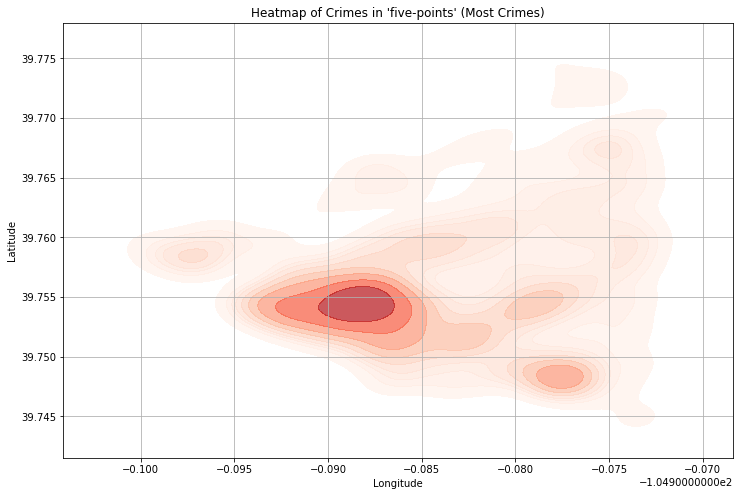

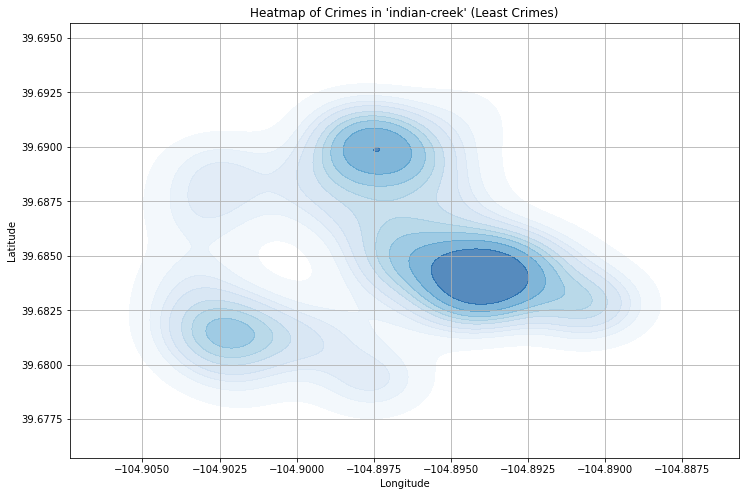

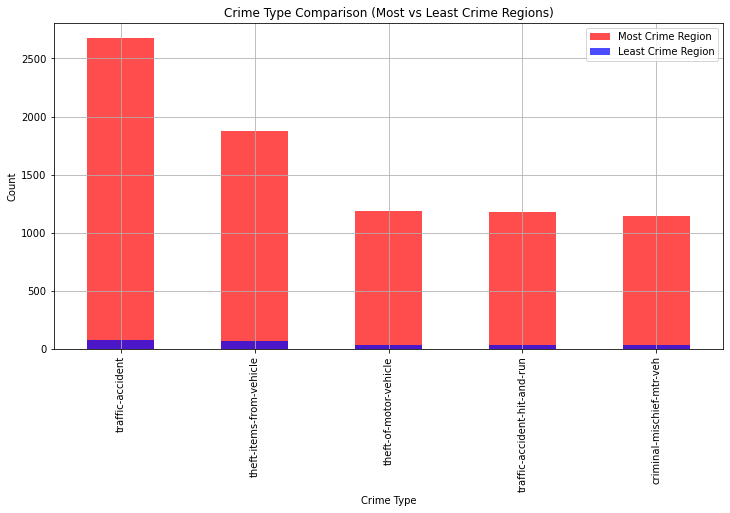

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
df = pd.read_csv(r'C:\Users\user\BDA_Data\Dataset\crime.csv')

# 'REPORTED_DATE'를 datetime 형식으로 변환
df['REPORTED_DATE'] = pd.to_datetime(df['REPORTED_DATE'])

# 지역별 범죄 건수 집계
if 'NEIGHBORHOOD_ID' in df.columns:
    region_crime_counts = df['NEIGHBORHOOD_ID'].value_counts()

    # 범죄가 가장 많이 발생한 지역과 가장 적게 발생한 지역
    most_crime_region = region_crime_counts.idxmax()
    least_crime_region = region_crime_counts.idxmin()

    print(f"Region with most crimes: {most_crime_region}, Count: {region_crime_counts.max()}")
    print(f"Region with least crimes: {least_crime_region}, Count: {region_crime_counts.min()}")

    # 해당 지역 데이터 필터링
    most_crime_data = df[df['NEIGHBORHOOD_ID'] == most_crime_region]
    least_crime_data = df[df['NEIGHBORHOOD_ID'] == least_crime_region]

    # 각 지역의 위도/경도 평균 계산
    most_crime_coords = most_crime_data[['GEO_LAT', 'GEO_LON']].mean()
    least_crime_coords = least_crime_data[['GEO_LAT', 'GEO_LON']].mean()

    print(f"\nMost Crime Region Coordinates (Average):\n{most_crime_coords}")
    print(f"Least Crime Region Coordinates (Average):\n{least_crime_coords}")

    # 범죄 유형 분포 비교
    most_crime_types = most_crime_data['OFFENSE_TYPE_ID'].value_counts()
    least_crime_types = least_crime_data['OFFENSE_TYPE_ID'].value_counts()

    print(f"\nMost Crime Region - Top Crime Types:\n{most_crime_types.head()}")
    print(f"Least Crime Region - Top Crime Types:\n{least_crime_types.head()}")

    # 1. 가장 많은 범죄가 발생한 지역의 히트맵
    plt.figure(figsize=(12, 8))
    sns.kdeplot(
        x=most_crime_data['GEO_LON'], 
        y=most_crime_data['GEO_LAT'], 
        cmap='Reds', fill=True, alpha=0.7
    )
    plt.title(f"Heatmap of Crimes in '{most_crime_region}' (Most Crimes)")
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True)
    plt.show()

    # 2. 가장 적은 범죄가 발생한 지역의 히트맵
    plt.figure(figsize=(12, 8))
    sns.kdeplot(
        x=least_crime_data['GEO_LON'], 
        y=least_crime_data['GEO_LAT'], 
        cmap='Blues', fill=True, alpha=0.7
    )
    plt.title(f"Heatmap of Crimes in '{least_crime_region}' (Least Crimes)")
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True)
    plt.show()

    # 3. 범죄 유형 분포 비교 시각화
    plt.figure(figsize=(12, 6))
    most_crime_types.head(5).plot(kind='bar', color='red', alpha=0.7, label='Most Crime Region')
    least_crime_types.head(5).plot(kind='bar', color='blue', alpha=0.7, label='Least Crime Region')
    plt.title('Crime Type Comparison (Most vs Least Crime Regions)')
    plt.xlabel('Crime Type')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Error: 'NEIGHBORHOOD_ID' column not found in the dataset.")


In [3]:
most_crime_region = region_crime_counts.idxmax()
least_crime_region = region_crime_counts.idxmin()

print(f"Region with most crimes: {most_crime_region}, Count: {region_crime_counts.max()}")
print(f"Region with least crimes: {least_crime_region}, Count: {region_crime_counts.min()}")

Region with most crimes: five-points, Count: 23466
Region with least crimes: indian-creek, Count: 570
